# 13 — Aggregate satisfaction, 3-class

The centerpiece, now in its **multiclass** form. With three output classes the
correction is no longer a ratio but a linear solve:

    p_hat = M @ p        M[i, j] = P(predict i | true j)

so `p = M⁻¹ p_hat`, projected back onto the simplex. Naive counting reports
`p_hat` and calls it `p` — biased for exactly the same reason as the binary
case, and worse here because the neutral class leaks in both directions.

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
from src.normalize import normalize, NORMALIZE_VERSION
OUT = REPO / "data_en"
LABELS = ["negative", "neutral", "positive"]

import joblib
from sklearn.metrics import accuracy_score
from src.predict import apply_temperature
from src.estimate import (confusion_matrix_rates, predicted_distribution,
                          acc_prevalence_multiclass, resample_to_distribution)

cfg = json.loads((REPO / "inference_config_en.json").read_text(encoding="utf-8"))
model = joblib.load(cfg["model_repo"])
T = cfg["temperature"]
ORDER = [cfg["class_order"].index(l) for l in LABELS]
hold = pd.read_csv(OUT / "hold.csv"); test = pd.read_csv(OUT / "test.csv")

def predict3(df):
    L = model.decision_function(df.text.fillna(""))[:, ORDER]
    return np.array(LABELS)[apply_temperature(L, T).argmax(1)]

yh, ph = hold.label.values, predict3(hold)
print(f"holdout {len(hold):,} | accuracy {accuracy_score(yh, ph):.4f}")

holdout 587 | accuracy 0.6746


In [2]:
M = confusion_matrix_rates(yh, ph, LABELS)
print("confusion matrix  M[i,j] = P(predict i | true j)   columns sum to 1")
print(pd.DataFrame(M, index=[f"pred {l}" for l in LABELS],
                   columns=[f"true {l}" for l in LABELS]).round(3).to_string())
print(f"\ncondition number: {np.linalg.cond(M):.1f}")
print("(high = classes poorly separable, correction extrapolates, widen the CI)")

confusion matrix  M[i,j] = P(predict i | true j)   columns sum to 1
               true negative  true neutral  true positive
pred negative          0.693         0.292          0.082
pred neutral           0.248         0.431          0.148
pred positive          0.059         0.277          0.770

condition number: 4.5
(high = classes poorly separable, correction extrapolates, widen the CI)


## Does the correction recover a known class mix?

Resample the holdout to a range of **known** distributions, then compare naive
counting against the corrected estimate at each one.

In [3]:
scenarios = [("mostly happy",      [0.10, 0.15, 0.75]),
             ("as observed",       [0.26, 0.22, 0.52]),
             ("balanced",          [0.33, 0.34, 0.33]),
             ("mostly unhappy",    [0.60, 0.20, 0.20]),
             ("crisis",            [0.80, 0.10, 0.10])]

rows = []
print(f"{'scenario':<16} {'':<10} {'negative':>9} {'neutral':>9} {'positive':>9}")
for name, target in scenarios:
    idx = resample_to_distribution(yh, target, LABELS, n=4000, seed=0)
    cc = predicted_distribution(ph[idx], LABELS)
    acc = acc_prevalence_multiclass(cc, M)
    rows.append((name, np.array(target), cc, acc))
    print(f"{name:<16} {'TRUTH':<10} " + " ".join(f"{v:>9.3f}" for v in target))
    print(f"{'':<16} {'count':<10} " + " ".join(f"{v:>9.3f}" for v in cc))
    print(f"{'':<16} {'corrected':<10} " + " ".join(f"{v:>9.3f}" for v in acc))
    print()

cc_mae = np.mean([np.abs(c - t).mean() for _, t, c, _ in rows])
ac_mae = np.mean([np.abs(a - t).mean() for _, t, _, a in rows])
print(f"MAE   counting {cc_mae:.4f}   corrected {ac_mae:.4f}   "
      f"-> {cc_mae/max(ac_mae,1e-9):.1f}x better")

scenario                     negative   neutral  positive
mostly happy     TRUTH          0.100     0.150     0.750
                 count          0.189     0.191     0.620
                 corrected      0.141     0.100     0.759

as observed      TRUTH          0.260     0.220     0.520
                 count          0.299     0.235     0.466
                 corrected      0.284     0.206     0.510

balanced         TRUTH          0.330     0.340     0.330
                 count          0.359     0.277     0.364
                 corrected      0.339     0.334     0.327

mostly unhappy   TRUTH          0.600     0.200     0.200
                 count          0.499     0.263     0.239
                 corrected      0.618     0.185     0.196

crisis           TRUTH          0.800     0.100     0.100
                 count          0.591     0.262     0.147
                 corrected      0.790     0.123     0.087

MAE   counting 0.0744   corrected 0.0166   -> 4.5x better


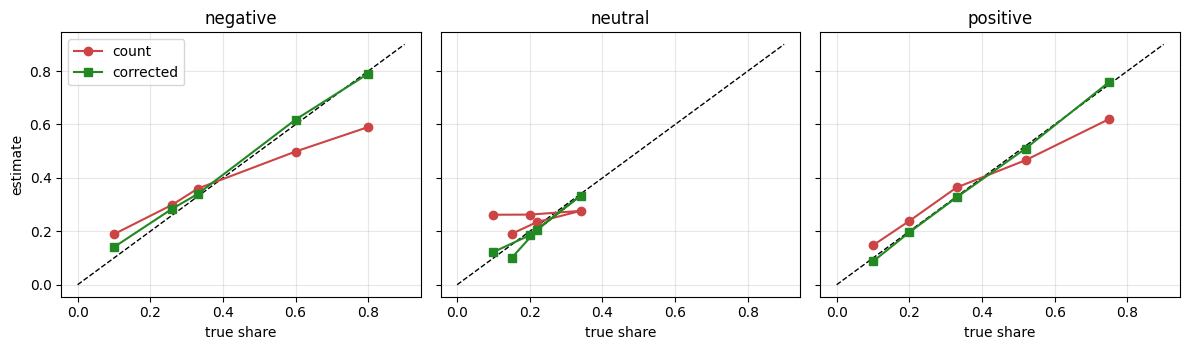

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, (li, lab) in zip(axes, enumerate(LABELS)):
    t = [r[1][li] for r in rows]; c = [r[2][li] for r in rows]; a = [r[3][li] for r in rows]
    ax.plot([0, .9], [0, .9], "k--", lw=1)
    ax.plot(t, c, "o-", color="#c44", label="count")
    ax.plot(t, a, "s-", color="#282", label="corrected")
    ax.set_title(lab); ax.set_xlabel("true share"); ax.grid(alpha=.3)
axes[0].set_ylabel("estimate"); axes[0].legend()
plt.tight_layout(); plt.savefig(OUT / "fig_cc_vs_acc.png", dpi=120); plt.show()

## The headline number, with an interval

Bootstrap over both the review sample and the holdout that produced `M`.

In [5]:
def satisfaction_with_ci(pred, M_, n_boot=1500, seed=0):
    rng = np.random.default_rng(seed)
    pt = acc_prevalence_multiclass(predicted_distribution(pred, LABELS), M_)
    draws = []
    for _ in range(n_boot):
        pb = pred[rng.integers(0, len(pred), len(pred))]
        hb = rng.integers(0, len(yh), len(yh))
        try:
            Mb = confusion_matrix_rates(yh[hb], ph[hb], LABELS)
            draws.append(acc_prevalence_multiclass(predicted_distribution(pb, LABELS), Mb))
        except ValueError:
            continue
    d = np.array(draws)
    return pt, np.percentile(d, 2.5, axis=0), np.percentile(d, 97.5, axis=0)

pt_test = predict3(test)
pt, lo, hi = satisfaction_with_ci(pt_test, M)
truth = predicted_distribution(test.label.values, LABELS)
naive = predicted_distribution(pt_test, LABELS)

print(f"TEST SET  n={len(test):,}\n")
print(f"{'class':<10} {'truth':>8} {'count':>8} {'corrected':>10} {'95% CI':>18}")
for i, l in enumerate(LABELS):
    print(f"{l:<10} {truth[i]:>8.3f} {naive[i]:>8.3f} {pt[i]:>10.3f} "
          f"  [{lo[i]:.3f}, {hi[i]:.3f}]")
cov = sum(lo[i] <= truth[i] <= hi[i] for i in range(3))
print(f"\nintervals containing truth: {cov}/3")
print(f"\nSATISFIED (positive): {pt[2]:.1%}  [{lo[2]:.1%}, {hi[2]:.1%}]"
      f"   truth {truth[2]:.1%}   naive {naive[2]:.1%}")

TEST SET  n=1,175

class         truth    count  corrected             95% CI
negative      0.261    0.320      0.356   [0.235, 0.458]
neutral       0.220    0.211      0.097   [0.000, 0.286]
positive      0.518    0.469      0.547   [0.453, 0.621]

intervals containing truth: 3/3

SATISFIED (positive): 54.7%  [45.3%, 62.1%]   truth 51.8%   naive 46.9%


In [6]:
c = json.loads((REPO / "inference_config_en.json").read_text(encoding="utf-8"))
c["confusion_matrix"] = [[round(float(x), 6) for x in row] for row in M]
(REPO / "inference_config_en.json").write_text(json.dumps(c, indent=2), encoding="utf-8")
json.dump({"cond_M": round(float(np.linalg.cond(M)), 2),
           "cc_mae": round(float(cc_mae), 4), "acc_mae": round(float(ac_mae), 4),
           "improvement_x": round(float(cc_mae/max(ac_mae,1e-9)), 1),
           "test": {"truth": truth.tolist(), "naive": naive.tolist(),
                    "corrected": pt.tolist(), "ci_low": lo.tolist(), "ci_high": hi.tolist()},
           "ci_coverage": f"{cov}/3"},
          open(OUT / "results_aggregate.json", "w"), indent=2)
print("saved results_aggregate.json + confusion matrix into the config")

saved results_aggregate.json + confusion matrix into the config
